# Análisis Exploratorio de Datos (EDA) - Dataset de Salarios (Census Income)

**Variables principales:**

- `age`: edad
- `workclass`: tipo de empleo
- `fnlwgt`: peso final (ponderación)
- `education`: nivel educativo
- `education-num`: años de educación
- `marital-status`: estado civil
- `occupation`: ocupación
- `relationship`: relación familiar
- `race`: raza
- `sex`: sexo
- `capital-gain`: ganancia de capital
- `capital-loss`: pérdida de capital
- `hours-per-week`: horas trabajadas por semana
- `native-country`: país de origen
- `salary`: ingreso (<=50K o >50K) -> **variable objetivo**

## 1. Importación de librerías

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import joblib
import warnings
warnings.filterwarnings('ignore')

In [139]:
# Configurar visualizaciones
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Carga de datos

In [140]:
# Cargar el dataset (asegúrate de que el archivo esté en la misma ruta)
df = pd.read_csv('salary.csv')

# Mostrar primeras filas
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [141]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  salary          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [142]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [143]:
# Verificar valores faltantes
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## 3. Análisis de la variable objetivo: `salary`

In [144]:
# Distribución de la variable objetivo
print(df['salary'].value_counts())
print(df['salary'].value_counts(normalize=True) * 100)

salary
<=50K    24720
>50K      7841
Name: count, dtype: int64
salary
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


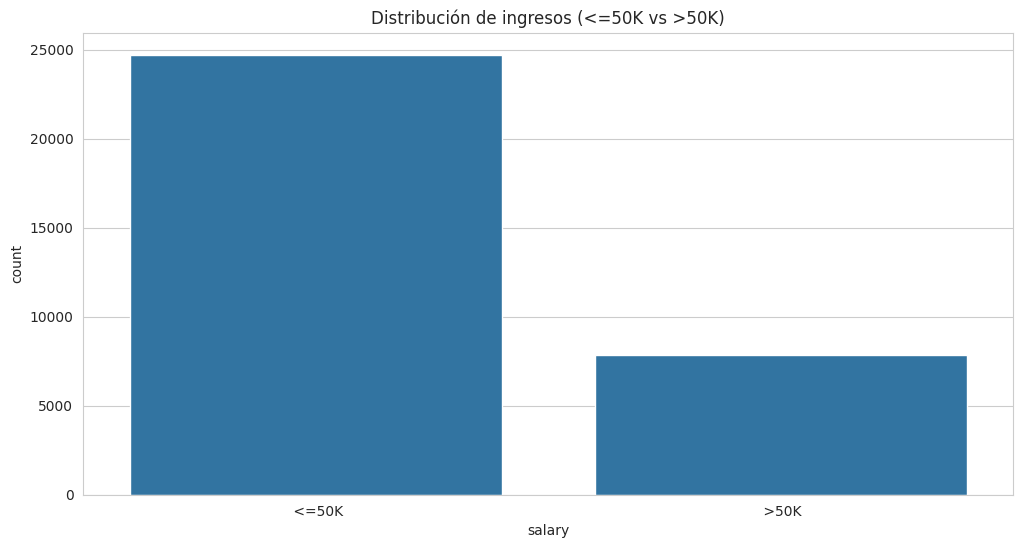

In [145]:
# Gráfico de barras
sns.countplot(data=df, x='salary')
plt.title('Distribución de ingresos (<=50K vs >50K)')
plt.show()

## 4. Análisis de variables numéricas

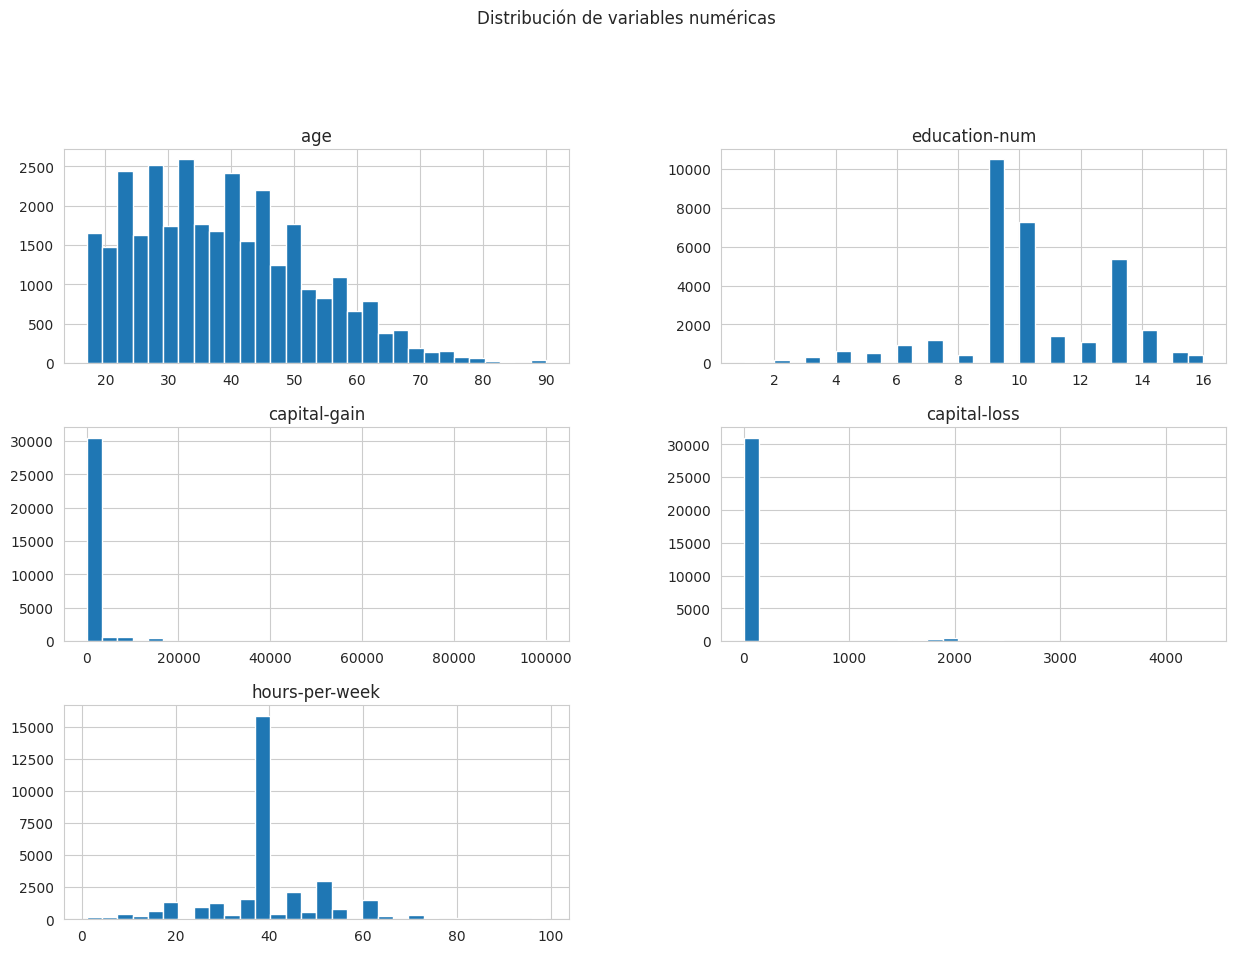

In [146]:
# Variables numéricas seleccionadas
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Histogramas
df[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribución de variables numéricas', y=1.02)
plt.show()

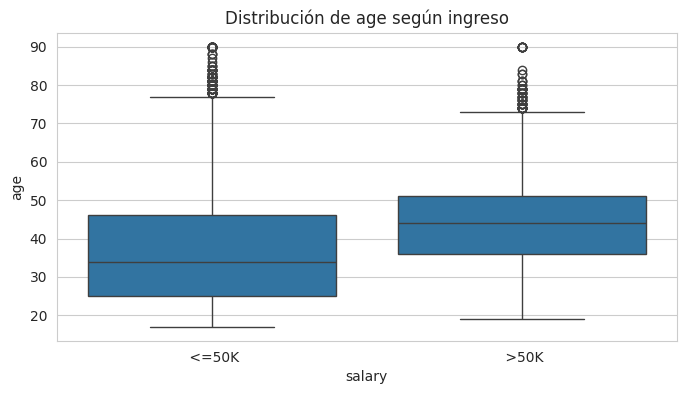

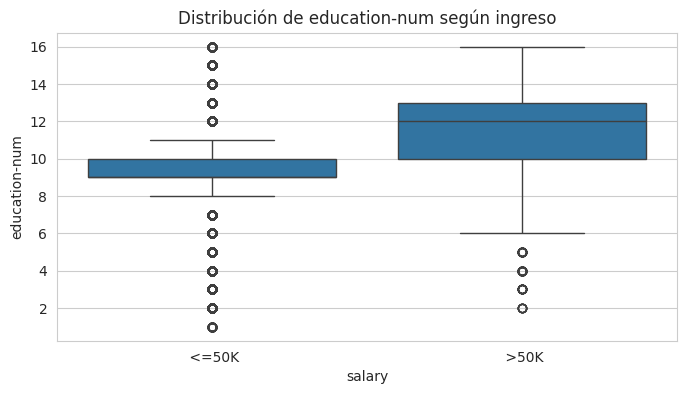

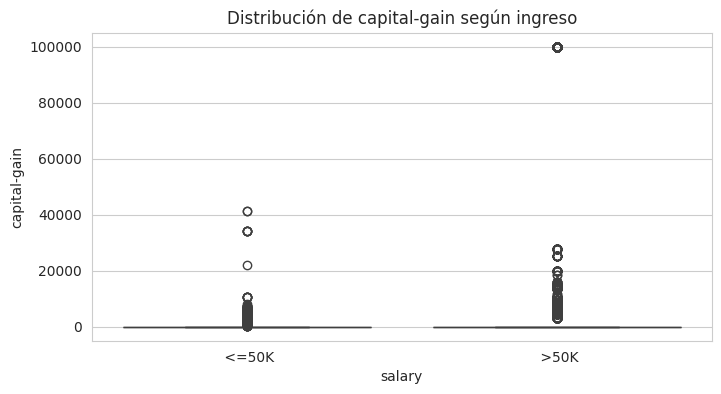

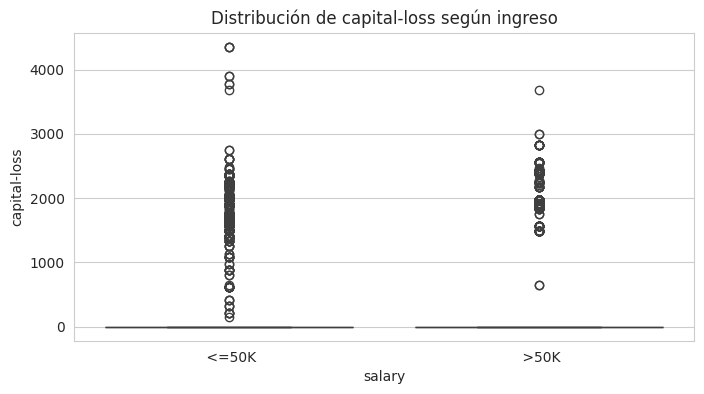

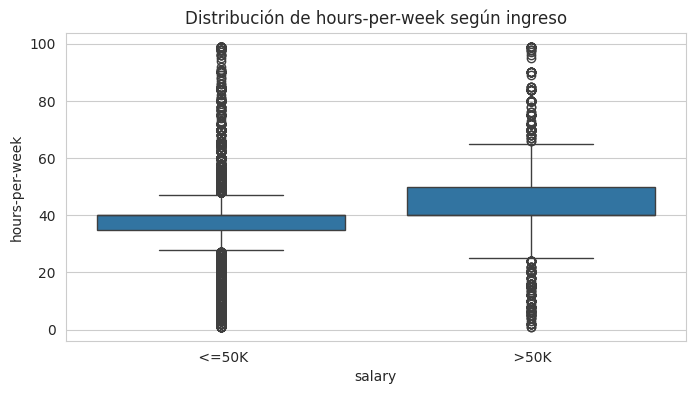

In [147]:
# Boxplots por categoría de salary
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='salary', y=col)
    plt.title(f'Distribución de {col} según ingreso')
    plt.show()

## 5. Análisis de variables categóricas

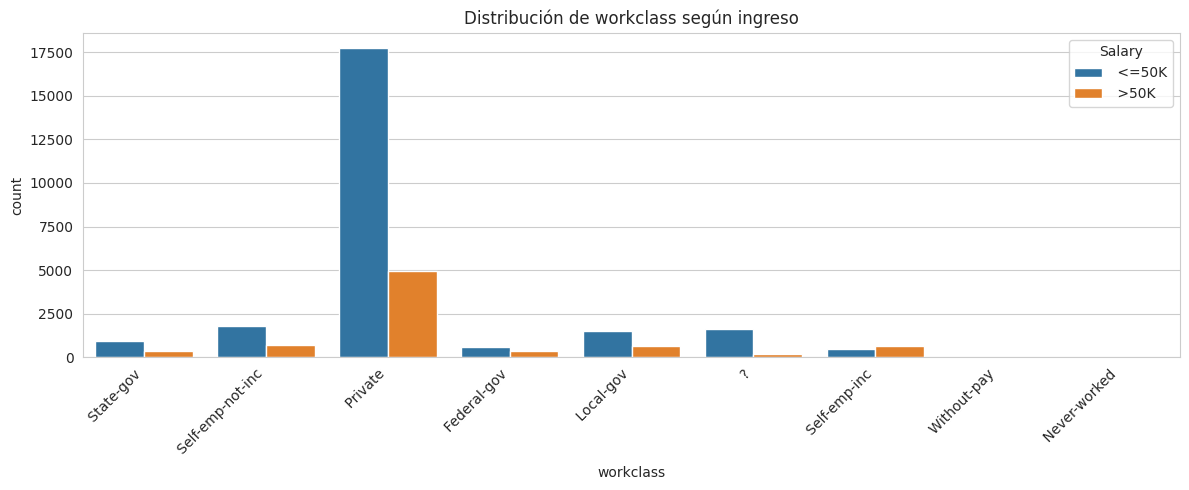

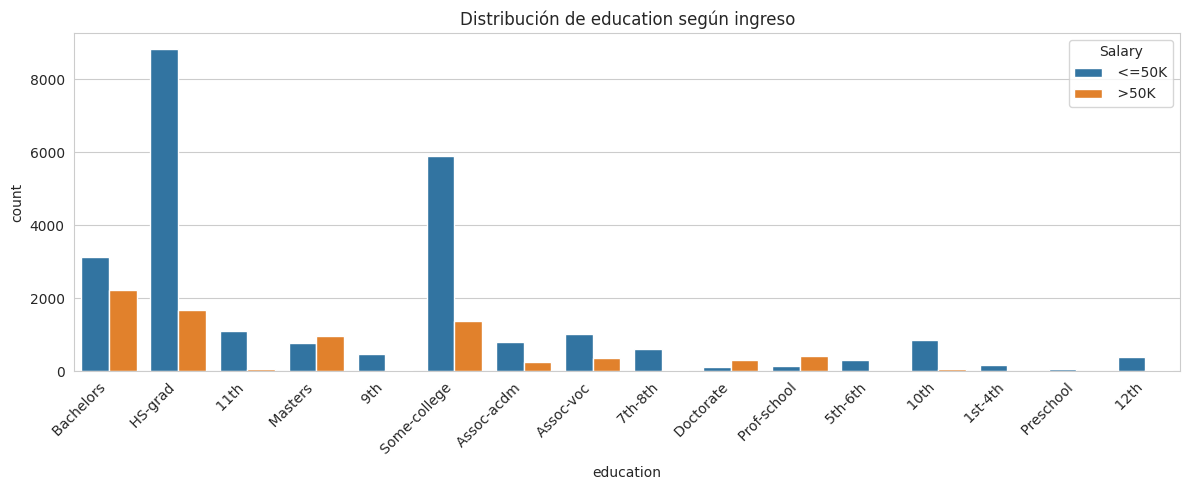

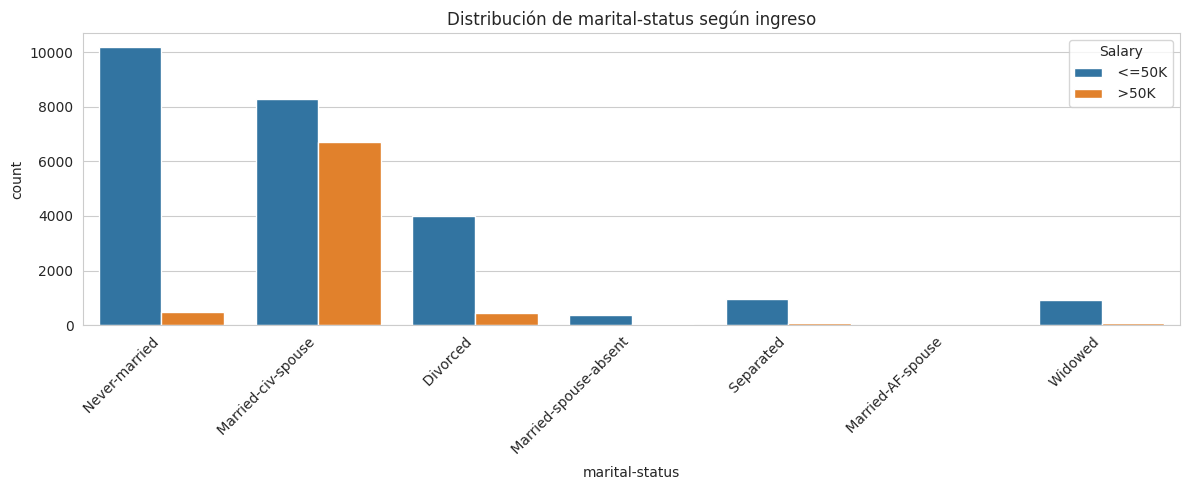

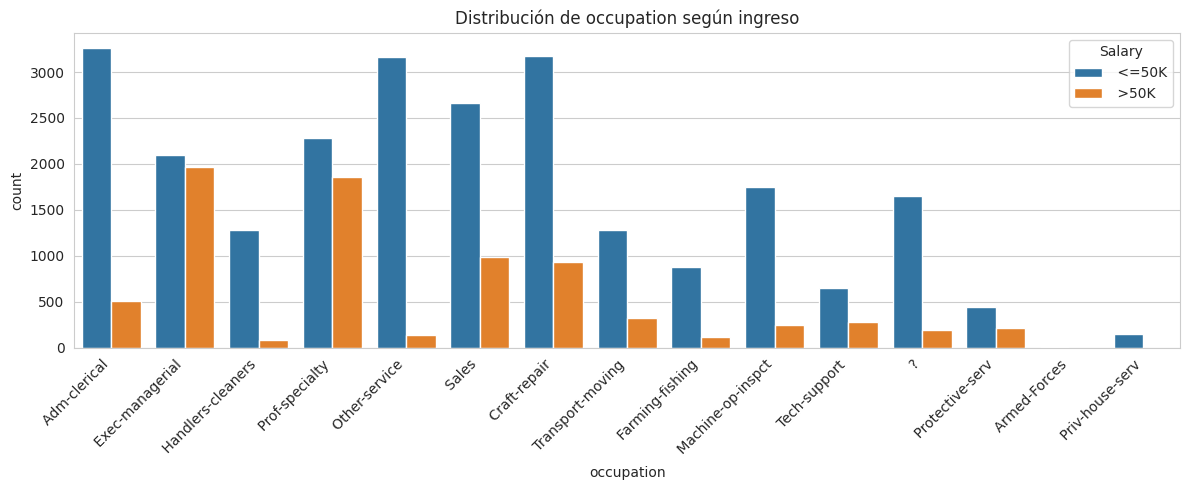

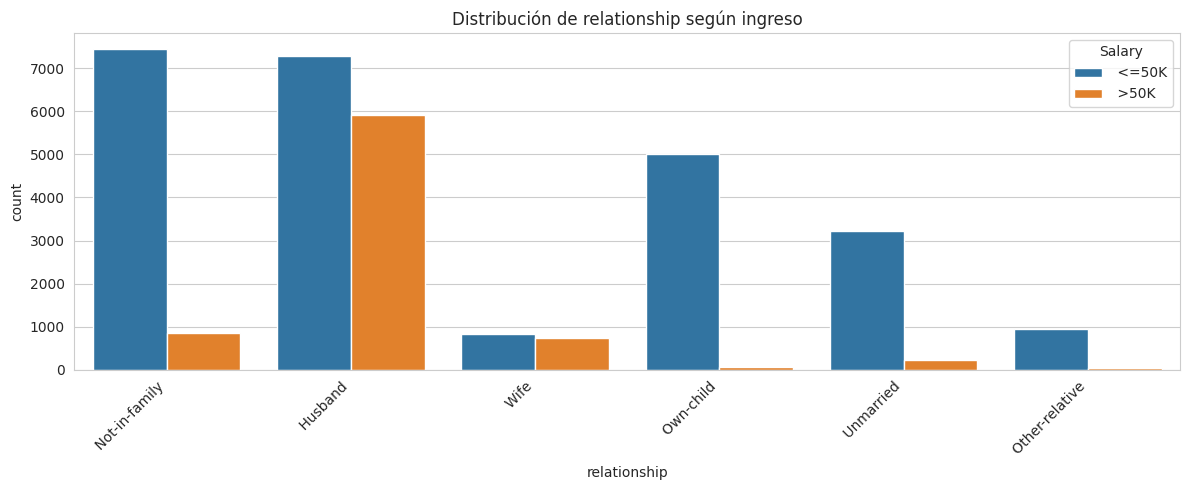

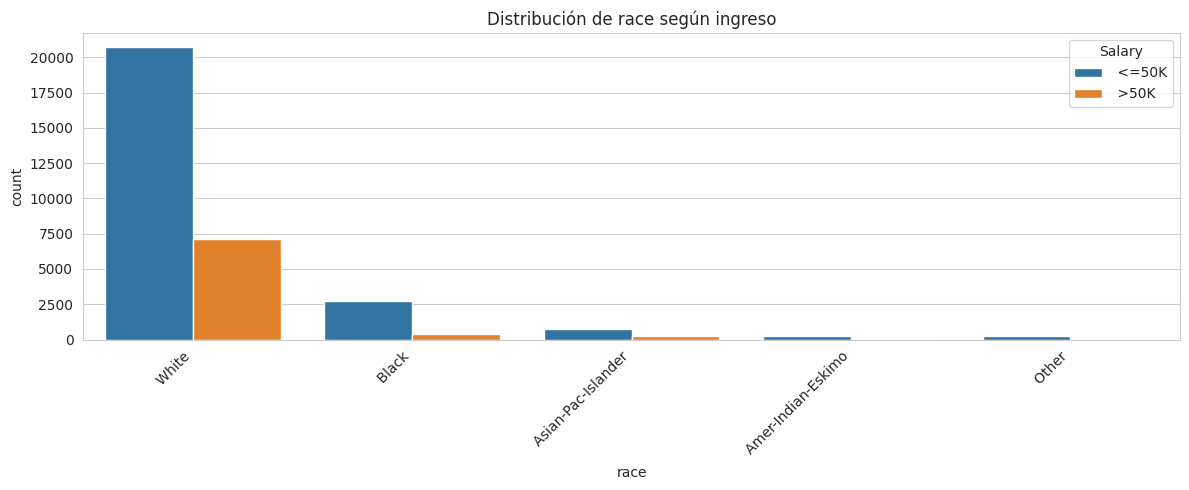

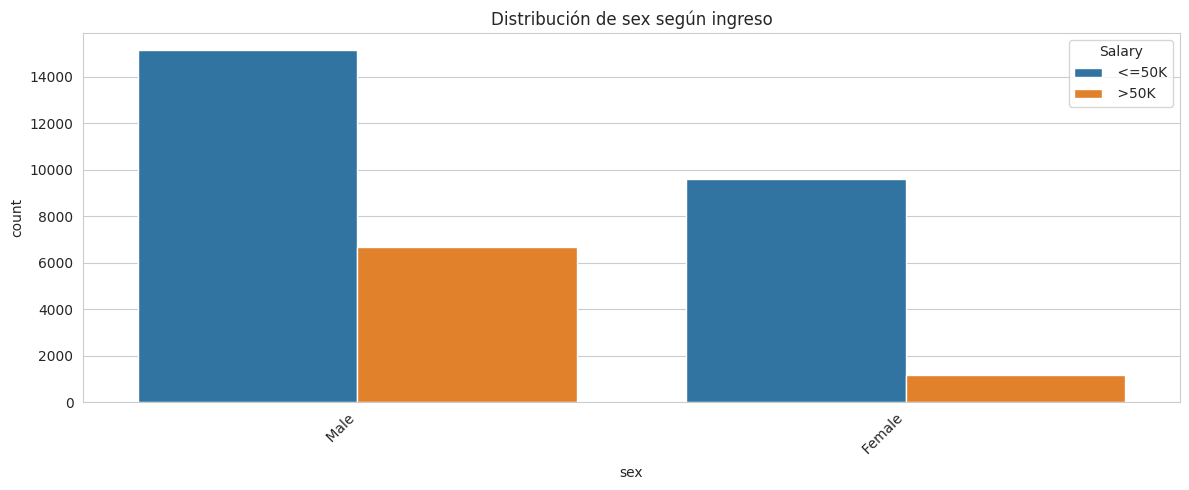

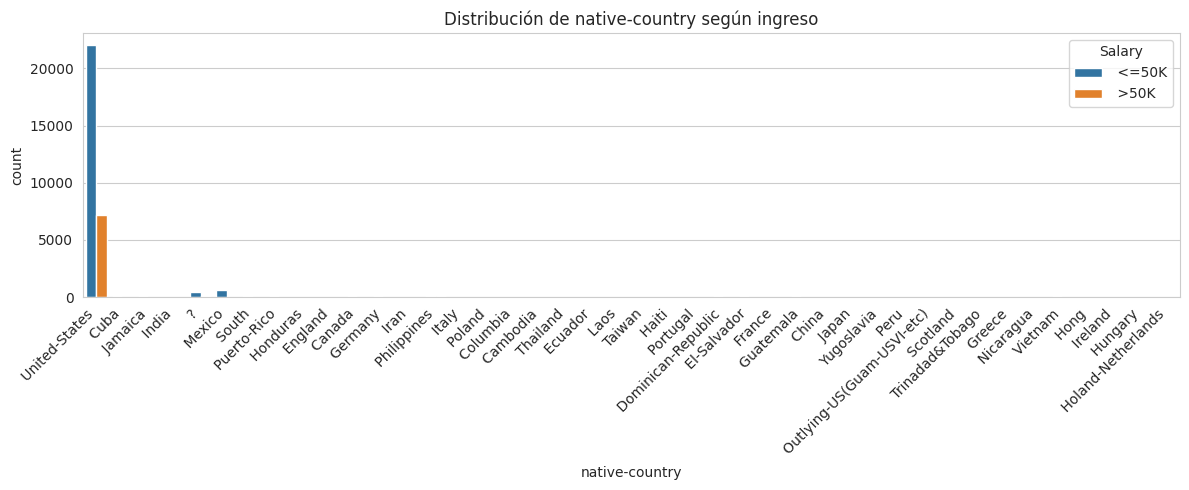

In [148]:
# Seleccionar variables categóricas relevantes
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

# Función para graficar proporciones
def plot_cat_vs_salary(col):
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, x=col, hue='salary')
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Distribución de {col} según ingreso')
    plt.legend(title='Salary')
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    plot_cat_vs_salary(col)

## 6. Relaciones entre variables numéricas (matriz de correlación)

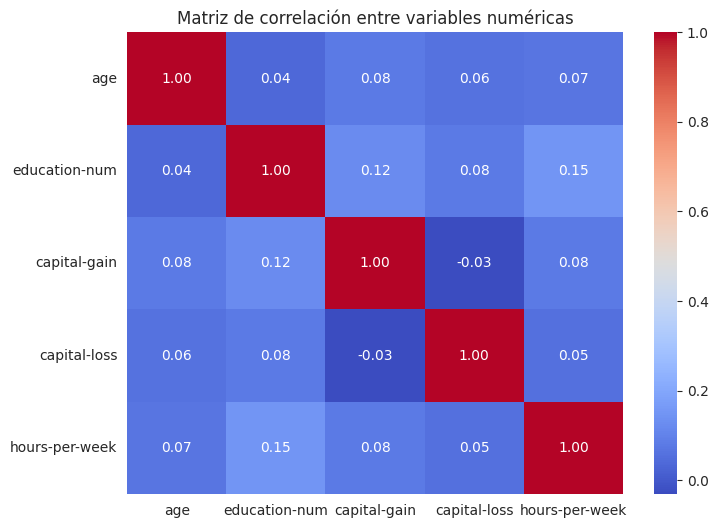

In [149]:
# Matriz de correlación
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables numéricas')
plt.show()

## 7. Análisis de valores atípicos (outliers) en variables numéricas

In [150]:
# Usar IQR para detectar outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)')

age: 143 outliers (0.44%)
education-num: 1198 outliers (3.68%)
capital-gain: 2712 outliers (8.33%)
capital-loss: 1519 outliers (4.67%)
hours-per-week: 9008 outliers (27.66%)


## 8. Resumen de insights clave

- **Desbalanceo**: La clase `<=50K` es mayoritaria (aprox. 75%).
- **Edad**: La mayoría de los individuos tienen entre 20 y 50 años.
- **Educación**: `HS-grad`, `Some-college` y `Bachelors` son los niveles más comunes.
- **Ganancias de capital**: Muy sesgada a la derecha (mayoría con 0).
- **Horas trabajadas**: Promedio alrededor de 40 horas.
- **Ocupaciones**: `Exec-managerial`, `Prof-specialty`, `Craft-repair` son frecuentes.
- **Sexo**: Hay más hombres que mujeres en el dataset.
- **Relación con ingreso**: Mayores ingresos se asocian con mayor edad, más educación, más horas, y ocupaciones como `Exec-managerial` y `Prof-specialty`.

# Preprocesamiento de Datos

**Pasos principales:**
1. Carga de datos
2. Separación de features (X) y target (y)
3. División en entrenamiento y prueba (estratificada)
4. Definición de pipelines para variables numéricas y categóricas
5. Aplicación del preprocesamiento
6. Verificación y guardado de conjuntos procesados

Se utilizan técnicas estándar: escalado, codificación one-hot, y manejo de valores faltantes.

## 1. Separación de features y target

In [151]:
# Variable objetivo
target = 'salary'
y = df[target]

# Features (todas las demás columnas)
X = df.drop(columns=[target])

# Verificar dimensiones
print(f"Tamaño de X: {X.shape}")
print(f"Tamaño de y: {y.shape}")

Tamaño de X: (32561, 14)
Tamaño de y: (32561,)


## 2. División en entrenamiento y prueba

In [152]:
# División estratificada para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} registros")
print(f"Tamaño de prueba: {X_test.shape[0]} registros")

Tamaño de entrenamiento: 22792 registros
Tamaño de prueba: 9769 registros


In [153]:
# Verificar balance en los conjuntos
print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)


Distribución de clases en entrenamiento:
salary
<=50K    75.916988
>50K     24.083012
Name: proportion, dtype: float64


In [154]:
print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True) * 100)


Distribución de clases en prueba:
salary
<=50K    75.923841
>50K     24.076159
Name: proportion, dtype: float64


## 3. Definición de pipelines de preprocesamiento

In [155]:
# Identificar columnas numéricas y categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Columnas numéricas: {num_cols}")
print(f"Columnas categóricas: {cat_cols}")

Columnas numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Columnas categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [156]:
# Pipeline para variables numéricas:
# - Imputación con la mediana (por si hay nulos)
# - Escalado estándar (StandardScaler)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas:
# - Imputación con la constante 'missing' (por si hay nulos)
# - One-Hot Encoding con manejo de categorías desconocidas (handle_unknown='ignore')
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [157]:
# Combinar pipelines en un ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

## 4. Aplicación del preprocesamiento

In [158]:
# Ajustar el preprocesador SOLO con los datos de entrenamiento
preprocessor.fit(X_train)

# Transformar conjuntos de entrenamiento y prueba
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Verificar dimensiones después del preprocesamiento
print(f"Dimensiones de X_train procesado: {X_train_processed.shape}")
print(f"Dimensiones de X_test procesado: {X_test_processed.shape}")

Dimensiones de X_train procesado: (22792, 108)
Dimensiones de X_test procesado: (9769, 108)


In [159]:
# Opcional: convertir a DataFrame para facilitar la visualización (solo para inspección)
# Obtener nombres de las columnas generadas
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

# Crear DataFrames (para inspección, no necesario para modelado)
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names)

# Mostrar primeras filas del conjunto de entrenamiento procesado
X_train_df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.323996,-0.888359,-1.187429,-0.146047,-0.215155,1.572934,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.510030,0.818890,-0.028839,-0.146047,3.775441,-1.648494,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.336253,0.094635,-0.028839,-0.146047,-0.215155,-0.037780,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-1.583391,-0.315857,-1.573625,-0.146047,-0.215155,-2.292780,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.177274,-0.100069,-0.028839,-0.146047,-0.215155,-0.359923,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 5. Verificación de balances y dimensiones finales

In [160]:
# Confirmar que no hay valores nulos en los conjuntos procesados
print("Nulos en X_train_processed:", np.isnan(X_train_processed).sum())
print("Nulos en X_test_processed:", np.isnan(X_test_processed).sum())

# Verificar la forma final
print(f"\nX_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Nulos en X_train_processed: 0
Nulos en X_test_processed: 0

X_train_processed shape: (22792, 108)
X_test_processed shape: (9769, 108)


## 6. Análisis de correlación post-preprocesamiento (opcional)

In [161]:
# Si se desea, se puede analizar la correlación de las variables procesadas con el target codificado
# Primero, codificar y en formato numérico (0/1)
y_train_bin = y_train.map({'<=50K': 0, '>50K': 1})

# Crear un DataFrame combinado para correlación
df_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names)
df_train_processed['salary_bin'] = y_train_bin.values

# Calcular correlación con el target y mostrar las 10 variables más correlacionadas
correlations = df_train_processed.corr()['salary_bin'].sort_values(ascending=False)
print("Top 10 características más correlacionadas con el ingreso:")
print(correlations.head(11))  # Incluye el target

Top 10 características más correlacionadas con el ingreso:
age                       NaN
fnlwgt                    NaN
education-num             NaN
capital-gain              NaN
capital-loss              NaN
hours-per-week            NaN
workclass_ ?              NaN
workclass_ Federal-gov    NaN
workclass_ Local-gov      NaN
workclass_ Never-worked   NaN
workclass_ Private        NaN
Name: salary_bin, dtype: float64


## 7. Guardado de conjuntos preprocesados

In [162]:
# Guardar en formato CSV (para usarlos en otros entornos)
pd.DataFrame(X_train_processed, columns=all_feature_names).to_csv('X_train_processed.csv', index=False)
pd.DataFrame(X_test_processed, columns=all_feature_names).to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Guardar el pipeline de preprocesamiento para usarlo en nuevos datos
joblib.dump(preprocessor, 'preprocessor.pkl')

print("Archivos del preprocesamiento guardados.")

Archivos del preprocesamiento guardados.


## 8. Resumen del preprocesamiento

**Variables numéricas escaladas** a media 0 y desviación 1 (StandardScaler).
- **Variables categóricas codificadas** con One-Hot Encoding (se generan múltiples columnas).
- **Conjuntos de entrenamiento y prueba** correctamente separados y preprocesados sin fuga de información.
- **El pipeline está listo** para ser utilizado en modelos de machine learning.
- **Los datos procesados** pueden guardarse para su uso posterior.

# Entrenamiento y Evaluación de Modelos - Dataset de Salarios

**Modelos:**
1. Regresión Logística (modelo lineal)
2. Random Forest (modelo no lineal)
3. Red Neuronal (Keras/TensorFlow)

**Métricas:** accuracy, precision, recall, F1-score, AUC-ROC y matrices de confusión.

## 1. Carga de datos preprocesados

In [163]:
try:
    X_train = pd.read_csv('X_train_processed.csv').values
    X_test = pd.read_csv('X_test_processed.csv').values
    y_train = pd.read_csv('y_train.csv').values.ravel()
    y_test = pd.read_csv('y_test.csv').values.ravel()
    print("Datos cargados desde archivos CSV.")
except FileNotFoundError:
    print("Archivos no encontrados. Por favor, asegúrate de haber ejecutado el preprocesamiento y guardado los archivos.")
    print("O bien, carga los datos directamente desde el preprocesamiento.")

Datos cargados desde archivos CSV.


In [164]:
# Convertir etiquetas a binario (0/1) para algunas métricas y redes neuronales
y_train_bin = np.array([1 if label == ' >50K' else 0 for label in y_train])
y_test_bin = np.array([1 if label == ' >50K' else 0 for label in y_test])

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")
print(f"Balance en entrenamiento: {np.mean(y_train_bin)*100:.2f}% >50K")
print(f"Balance en prueba: {np.mean(y_test_bin)*100:.2f}% >50K")

Dimensiones de entrenamiento: (22792, 108)
Dimensiones de prueba: (9769, 108)
Balance en entrenamiento: 24.08% >50K
Balance en prueba: 24.08% >50K


## 2. Modelo 1: Regresión Logística

In [165]:
# Entrenar Regresión Logística con balanceo de clases
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [166]:
# Predicciones
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]  # probabilidades para clase positiva

In [167]:
# Métricas
print("=== REGRESIÓN LOGÍSTICA ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logreg, pos_label=' >50K'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logreg, pos_label=' >50K'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_logreg, pos_label=' >50K'):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test_bin, y_proba_logreg):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

=== REGRESIÓN LOGÍSTICA ===
Accuracy: 0.8094
Precision: 0.5693
Recall: 0.8559
F1-score: 0.6838
AUC-ROC: 0.9085

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.95      0.79      0.86      7417
        >50K       0.57      0.86      0.68      2352

    accuracy                           0.81      9769
   macro avg       0.76      0.83      0.77      9769
weighted avg       0.86      0.81      0.82      9769



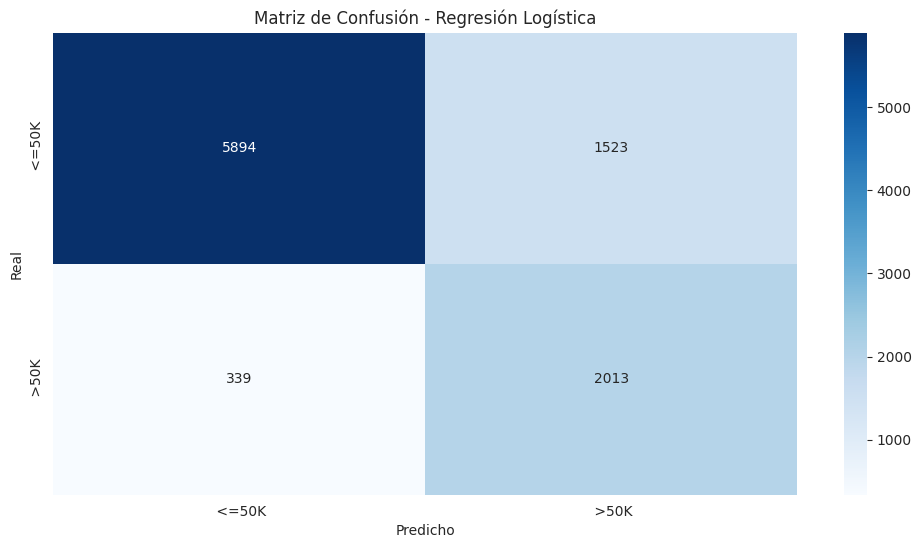

In [168]:
# Matriz de confusión
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=[' <=50K', ' >50K'])
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues', xticklabels=[' <=50K', ' >50K'], yticklabels=[' <=50K', ' >50K'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

## 3. Modelo 2: Random Forest

In [169]:
# Entrenar Random Forest con ajuste de hiperparámetros básico
rf = RandomForestClassifier(n_estimators=100, max_depth=15,
                            class_weight='balanced', random_state=42,
                            n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=-1,
                       random_state=42)

In [170]:
# Predicciones
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [171]:
# Métricas
print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label=' >50K'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label=' >50K'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf, pos_label=' >50K'):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test_bin, y_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.8073
Precision: 0.5651
Recall: 0.8673
F1-score: 0.6843
AUC-ROC: 0.9140

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.95      0.79      0.86      7417
        >50K       0.57      0.87      0.68      2352

    accuracy                           0.81      9769
   macro avg       0.76      0.83      0.77      9769
weighted avg       0.86      0.81      0.82      9769



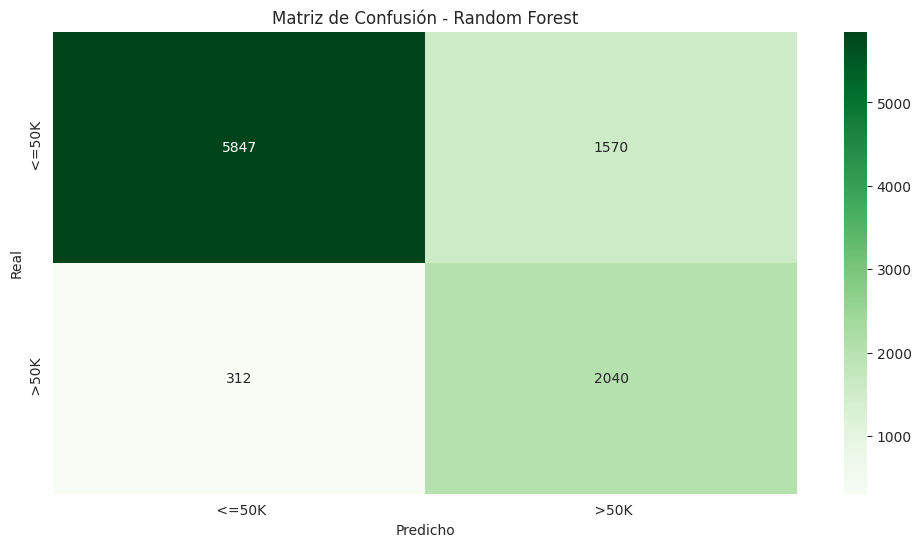

In [172]:
# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[' <=50K', ' >50K'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=[' <=50K', ' >50K'], yticklabels=[' <=50K', ' >50K'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

## 4. Modelo 3: Red Neuronal (Keras/TensorFlow)

In [173]:
# Construir la red neuronal
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # clasificación binaria
])

In [174]:
# Compilar
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), keras.metrics.AUC(name='auc')])

In [175]:
# Callbacks: early stopping para evitar sobreajuste
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [176]:
# Entrenar (usar y_train_bin)
history = model.fit(X_train, y_train_bin,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=128,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8100 - auc: 0.8297 - loss: 0.4096 - precision_2: 0.6865 - recall_2: 0.3674 - val_accuracy: 0.8331 - val_auc: 0.8929 - val_loss: 0.3497 - val_precision_2: 0.7041 - val_recall_2: 0.5943
Epoch 2/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8464 - auc: 0.8957 - loss: 0.3344 - precision_2: 0.7101 - recall_2: 0.5966 - val_accuracy: 0.8410 - val_auc: 0.9022 - val_loss: 0.3349 - val_precision_2: 0.7076 - val_recall_2: 0.6400
Epoch 3/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8496 - auc: 0.9030 - loss: 0.3233 - precision_2: 0.7163 - recall_2: 0.6067 - val_accuracy: 0.8432 - val_auc: 0.9040 - val_loss: 0.3310 - val_precision_2: 0.7308 - val_recall_2: 0.6081
Epoch 4/100
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8550 - auc: 0.9075 - loss: 0.3156 - precision_2: 0.7325 - recall_2: 0.6130 - val_accuracy: 0.8419 - val_auc: 0.9054 - val_loss: 0.3282 - val_precision_2: 0.7316 - val_recall_2: 0.5

In [177]:
# Evaluar en test
loss, acc, prec, rec, auc_keras = model.evaluate(X_test, y_test_bin, verbose=0)

print("=== RED NEURONAL ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"AUC-ROC: {auc_keras:.4f}")

=== RED NEURONAL ===
Accuracy: 0.8607
Precision: 0.7334
Recall: 0.6620
AUC-ROC: 0.9153


In [178]:
# Predicciones
y_proba_nn = model.predict(X_test).ravel()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [179]:
# Convertir a etiquetas originales para el reporte
y_pred_nn_labels = np.array([' >50K' if p == 1 else ' <=50K' for p in y_pred_nn])
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn_labels))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.90      0.92      0.91      7417
        >50K       0.73      0.66      0.70      2352

    accuracy                           0.86      9769
   macro avg       0.81      0.79      0.80      9769
weighted avg       0.86      0.86      0.86      9769



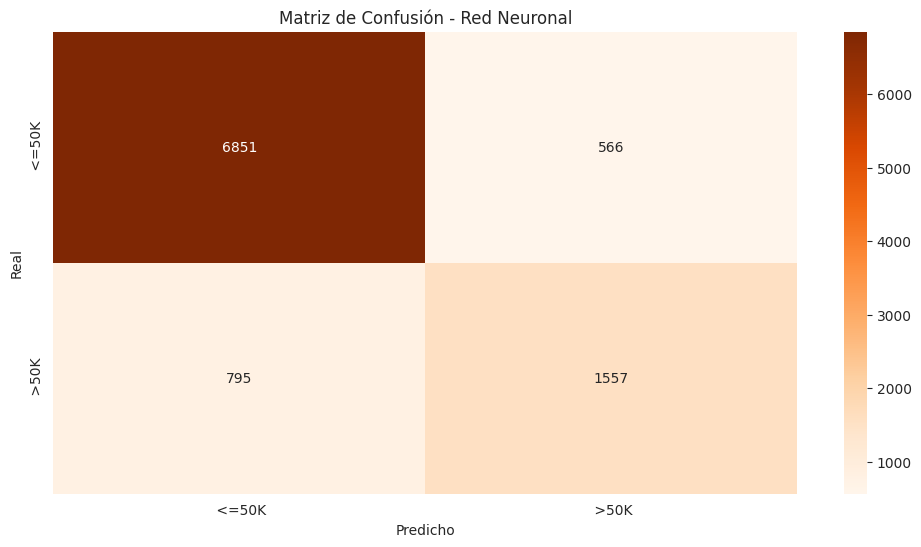

In [180]:
# Matriz de confusión
cm_nn = confusion_matrix(y_test, y_pred_nn_labels, labels=[' <=50K', ' >50K'])
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Oranges', xticklabels=[' <=50K', ' >50K'], yticklabels=[' <=50K', ' >50K'])
plt.title('Matriz de Confusión - Red Neuronal')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

## 5. Comparación de modelos

In [181]:
# Recopilar métricas en un DataFrame para comparar
models = ['Logistic Regression', 'Random Forest', 'Neural Network']
accuracies = [
    accuracy_score(y_test, y_pred_logreg),
    accuracy_score(y_test, y_pred_rf),
    acc
]
precisions = [
    precision_score(y_test, y_pred_logreg, pos_label=' >50K'),
    precision_score(y_test, y_pred_rf, pos_label=' >50K'),
    prec
]
recalls = [
    recall_score(y_test, y_pred_logreg, pos_label=' >50K'),
    recall_score(y_test, y_pred_rf, pos_label=' >50K'),
    rec
]
f1s = [
    f1_score(y_test, y_pred_logreg, pos_label=' >50K'),
    f1_score(y_test, y_pred_rf, pos_label=' >50K'),
    f1_score(y_test, y_pred_nn_labels, pos_label=' >50K')
]
aucs = [
    roc_auc_score(y_test_bin, y_proba_logreg),
    roc_auc_score(y_test_bin, y_proba_rf),
    auc_keras
]

comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1s,
    'AUC-ROC': aucs
})

print("=== COMPARACIÓN DE MODELOS ===")
print(comparison_df.to_string(index=False))

=== COMPARACIÓN DE MODELOS ===
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  0.809397   0.569287 0.855867  0.683764 0.908475
      Random Forest  0.807350   0.565097 0.867347  0.684334 0.913989
     Neural Network  0.860682   0.733396 0.661990  0.695866 0.915325


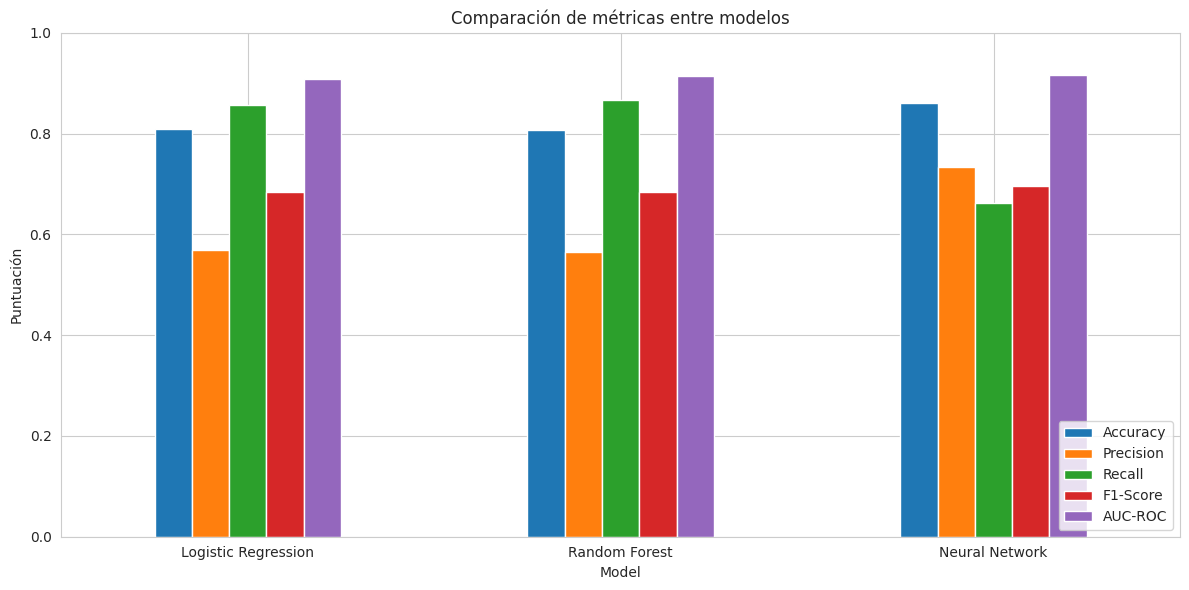

In [182]:
# Gráfico de barras comparativo
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de métricas entre modelos')
plt.ylabel('Puntuación')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Curvas ROC

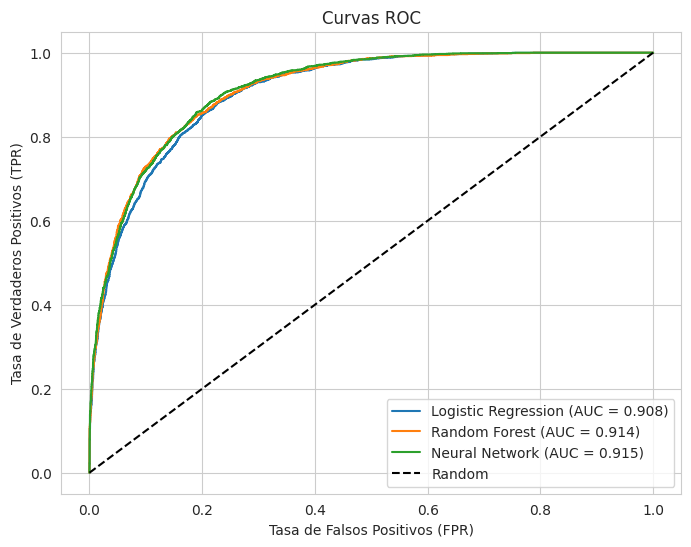

In [183]:
# Curvas ROC para los tres modelos
plt.figure(figsize=(8, 6))

fpr_logreg, tpr_logreg, _ = roc_curve(y_test_bin, y_proba_logreg)
fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, y_proba_rf)
fpr_nn, tpr_nn, _ = roc_curve(y_test_bin, y_proba_nn)

plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {aucs[0]:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {aucs[1]:.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {aucs[2]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC')
plt.legend()
plt.grid(True)
plt.show()

## 7. Guardado de modelos

In [184]:
# Guardar modelos entrenados para uso futuro
joblib.dump(logreg, 'logreg_model.pkl')
joblib.dump(rf, 'rf_model.pkl')
model.save('neural_network_model.keras')  # Guardar en formato Keras

print("Modelos guardados correctamente.")

Modelos guardados correctamente.


# Tuneo de Hiperparámetros - Random Forest

**Objetivo:** Mejorar el Recall y el AUC-ROC del modelo base, manteniendo un buen balance general.

**Estrategia:** Búsqueda aleatoria con validación cruzada estratificada (5 folds) optimizando el AUC-ROC.

## 1. Definición del espacio de búsqueda de hiperparámetros

In [208]:
feature_names = pd.read_csv('X_train_processed.csv').columns.tolist()
print("Nombres de las características:", feature_names)

Nombres de las características: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'education_ 10th', 'education_ 11th', 'education_ 12th', 'education_ 1st-4th', 'education_ 5th-6th', 'education_ 7th-8th', 'education_ 9th', 'education_ Assoc-acdm', 'education_ Assoc-voc', 'education_ Bachelors', 'education_ Doctorate', 'education_ HS-grad', 'education_ Masters', 'education_ Preschool', 'education_ Prof-school', 'education_ Some-college', 'marital-status_ Divorced', 'marital-status_ Married-AF-spouse', 'marital-status_ Married-civ-spouse', 'marital-status_ Married-spouse-absent', 'marital-status_ Never-married', 'marital-status_ Separated', 'marital-status_ Widowed', 'occupation_ ?', 'occupation_ Adm-clerical', 'occupation_ Armed-Forc

In [212]:
# Espacio de búsqueda para RandomizedSearchCV
param_dist = {
    # Número de árboles (más árboles = mayor estabilidad, pero más lento)
    'n_estimators': [100, 200, 300, 500],

    # Profundidad máxima del árbol (None permite crecimiento completo, pero puede sobreajustar)
    'max_depth': [10, 15, 20, 30, None],

    # Número mínimo de muestras para dividir un nodo (controla sobreajuste)
    'min_samples_split': [2, 5, 10],

    # Número mínimo de muestras en una hoja (controla sobreajuste)
    'min_samples_leaf': [1, 2, 4],

    # Número de características a considerar en cada división (controla aleatoriedad)
    'max_features': ['sqrt', 'log2', None],

    # Pesos de clase para manejar el desbalanceo
    'class_weight': [
        'balanced',
        'balanced_subsample',
        {0: 1, 1: 2},   # Doble peso a la clase >50K
        {0: 1, 1: 3},   # Triple peso a la clase >50K
        {0: 1, 1: 4}    # Cuádruple peso a la clase >50K (más agresivo)
    ],

    # Criterio de división
    'criterion': ['gini', 'entropy']
}

print("Espacio de búsqueda definido:")
for key, value in param_dist.items():
    print(f"  {key}: {value}")

Espacio de búsqueda definido:
  n_estimators: [100, 200, 300, 500]
  max_depth: [10, 15, 20, 30, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2', None]
  class_weight: ['balanced', 'balanced_subsample', {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 4}]
  criterion: ['gini', 'entropy']


## 2. Configuración de RandomizedSearchCV

In [186]:
# Modelo base
rf_base = RandomForestClassifier(random_state=42)

# Validación cruzada estratificada (para mantener proporción de clases)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,               # Número de combinaciones a probar (ajusta según tiempo)
    cv=cv,
    scoring='roc_auc',       # Optimizamos AUC-ROC (balancea bien ambas clases)
    n_jobs=-1,               # Usar todos los núcleos del procesador
    random_state=42,
    verbose=2,               # Muestra progreso
    return_train_score=True  # Para monitorear overfitting
)

## 3. Entrenamiento de la búsqueda (tuneo)

In [187]:
print("Iniciando RandomizedSearchCV... (esto puede tomar varios minutos)")
print(f"Se probarán {random_search.n_iter} combinaciones con validación cruzada de 5 folds.")

# Entrenar
random_search.fit(X_train, y_train)

Iniciando RandomizedSearchCV... (esto puede tomar varios minutos)
Se probarán 50 combinaciones con validación cruzada de 5 folds.
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(random_state=42), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample',
                                                         {0: 1, 1: 2},
                                                         {0: 1, 1: 3},
                                                         {0: 1, 1: 4}],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [10, 15, 20, 30, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, return_train_score=True, scoring='roc_auc',
                   verbose=2)

In [188]:
# Resultados
print("\n=== MEJOR RESULTADO ENCONTRADO ===")
print(f"Mejor puntuación (AUC-ROC) en validación: {random_search.best_score_:.4f}")
print("Mejores hiperparámetros:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")


=== MEJOR RESULTADO ENCONTRADO ===
Mejor puntuación (AUC-ROC) en validación: 0.9149
Mejores hiperparámetros:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 1
  max_features: None
  max_depth: 15
  criterion: entropy
  class_weight: balanced_subsample


## 4. Evaluación del modelo tuneado en el conjunto de prueba

In [189]:
# Mejor modelo
best_rf = random_search.best_estimator_

In [190]:
# Predicciones
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

In [192]:
# Métricas
print("=== MÉTRICAS DEL MODELO TUNEADO (TEST) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best, pos_label=' >50K'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best, pos_label=' >50K'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_best, pos_label=' >50K'):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_bin, y_proba_best):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

=== MÉTRICAS DEL MODELO TUNEADO (TEST) ===
Accuracy:  0.8331
Precision: 0.6132
Recall:    0.8312
F1-Score:  0.7058
AUC-ROC:   0.9191

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.83      0.88      7417
        >50K       0.61      0.83      0.71      2352

    accuracy                           0.83      9769
   macro avg       0.78      0.83      0.79      9769
weighted avg       0.86      0.83      0.84      9769



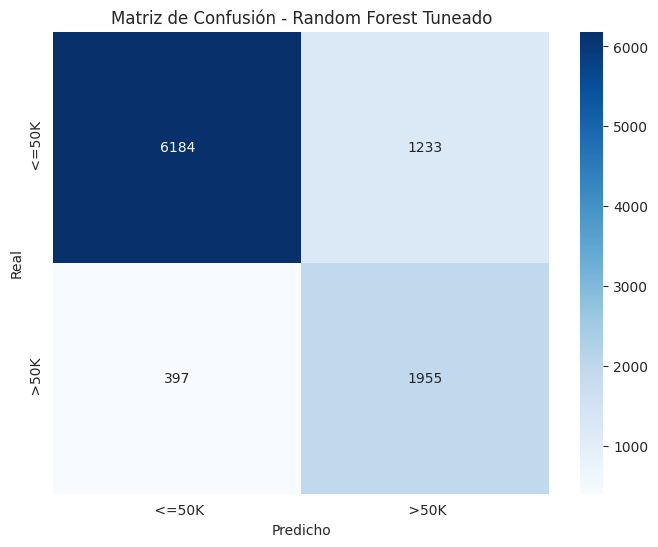

In [194]:
# Matriz de confusión
cm_best = confusion_matrix(y_test, y_pred_best, labels=[' <=50K', ' >50K'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=[' <=50K', ' >50K'],
            yticklabels=[' <=50K', ' >50K'])
plt.title('Matriz de Confusión - Random Forest Tuneado')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

## 5. Comparación con el modelo base (sin tunear)

In [196]:
# Predicciones base
y_pred_base = rf.predict(X_test)
y_proba_base = rf.predict_proba(X_test)[:, 1]

In [198]:
# Métricas base
metrics_base = {
    'Accuracy': accuracy_score(y_test, y_pred_base),
    'Precision': precision_score(y_test, y_pred_base, pos_label=' >50K'),
    'Recall': recall_score(y_test, y_pred_base, pos_label=' >50K'),
    'F1-Score': f1_score(y_test, y_pred_base, pos_label=' >50K'),
    'AUC-ROC': roc_auc_score(y_test_bin, y_proba_base)
}


In [199]:
# Métricas del tuneado
metrics_tuned = {
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'Precision': precision_score(y_test, y_pred_best, pos_label=' >50K'),
    'Recall': recall_score(y_test, y_pred_best, pos_label=' >50K'),
    'F1-Score': f1_score(y_test, y_pred_best, pos_label=' >50K'),
    'AUC-ROC': roc_auc_score(y_test_bin, y_proba_best)
}

In [200]:
# Crear DataFrame de comparación
comparison_df = pd.DataFrame({
    'Modelo Base': metrics_base,
    'Modelo Tuneado': metrics_tuned
}).T

print("=== COMPARACIÓN: BASE vs TUNEADO ===")
print(comparison_df.round(4))

=== COMPARACIÓN: BASE vs TUNEADO ===
                Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo Base       0.8073     0.5651  0.8673    0.6843   0.9140
Modelo Tuneado    0.8331     0.6132  0.8312    0.7058   0.9191


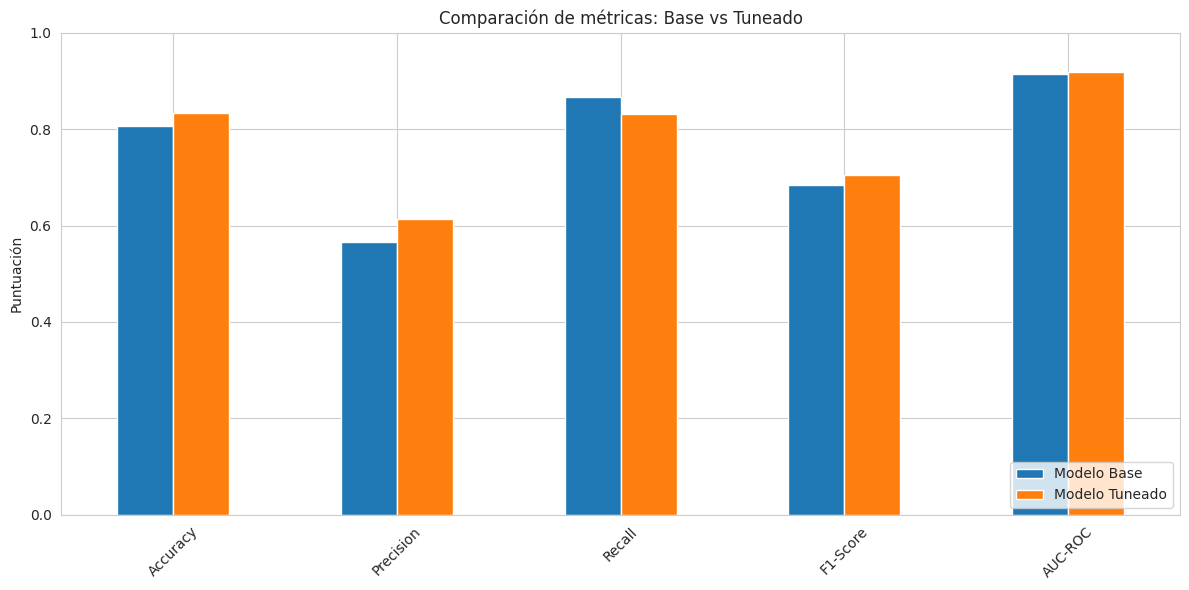

In [201]:
# Graficar comparación
comparison_df.T.plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de métricas: Base vs Tuneado')
plt.ylabel('Puntuación')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Curvas ROC comparativas

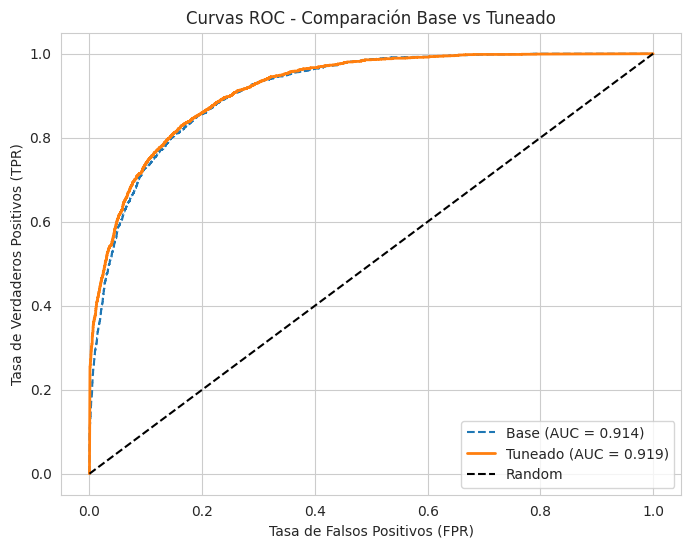

In [202]:
plt.figure(figsize=(8, 6))

# Curva del modelo base
fpr_base, tpr_base, _ = roc_curve(y_test_bin, y_proba_base)
plt.plot(fpr_base, tpr_base, label=f'Base (AUC = {metrics_base["AUC-ROC"]:.3f})', linestyle='--')

# Curva del modelo tuneado
fpr_best, tpr_best, _ = roc_curve(y_test_bin, y_proba_best)
plt.plot(fpr_best, tpr_best, label=f'Tuneado (AUC = {metrics_tuned["AUC-ROC"]:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparación Base vs Tuneado')
plt.legend()
plt.grid(True)
plt.show()

## 7. Importancia de características (Top 20)

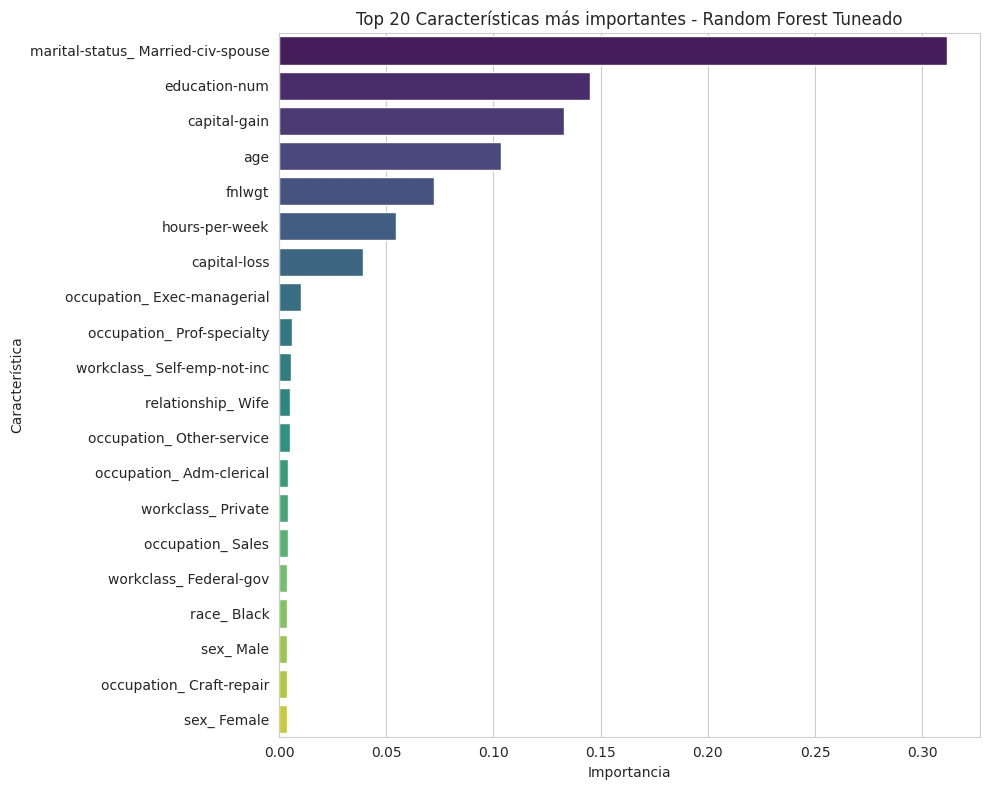

In [209]:
# Obtener importancias del modelo tuneado
importances = best_rf.feature_importances_

# Crear DataFrame con características e importancias
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 20
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Características más importantes - Random Forest Tuneado')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

In [210]:
print("Top 5 características más importantes:")
print(top_features.head(5).to_string(index=False))

Top 5 características más importantes:
                           feature  importance
marital-status_ Married-civ-spouse    0.311306
                     education-num    0.145141
                      capital-gain    0.132996
                               age    0.103585
                            fnlwgt    0.072348


## 8. Guardado del modelo tuneado

In [211]:
# Guardar el mejor modelo tuneado
joblib.dump(best_rf, 'random_forest_tuned.pkl')

# Guardar también el objeto de búsqueda (opcional, para análisis)
joblib.dump(random_search, 'random_search_rf.pkl')

print("Se ha guardado el modelo tuneado: random_forest_tuned.pkl")

Se ha guardado el modelo tuneado: random_forest_tuned.pkl
